In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#pd.set_option('display.max_columns', None)
#pd.reset_option('display.max_columns')
#pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')

# Funções auxiliares
def calcular_corr_relevantes(df, taxa_relevancia=0.5):
    """
        Calcula correlação entre variáveis do df. 
        Filtra os valores pela taxa_relevancia.
        Retorna apenas as linhas ou colunas com pelo menos um valor diferente de na
    """
    df_corr = df.corr()
    
    df_corr_relevantes = df_corr[
        ((df_corr > taxa_relevancia) & (df_corr < 1))
        |((df_corr < -taxa_relevancia) & (df_corr > -1))]
    df_corr_relevantes.dropna(how='all',inplace=True)
    df_corr_relevantes.dropna(how='all',inplace=True,axis=1)
    # matriz esparssa. Provavelmente simétrica também
    return df_corr_relevantes

# EDA

- Podemos ver que os dados possuem tipos variados. 38 colunas do tipo numérico e 43 colunas do tipo categórica

In [2]:
df_treino = pd.read_csv('../input/train.csv')
#df_treino = df_treino.drop(['Id'],axis=1)
#df_treino
df_treino.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [3]:
#df_treino.select_dtypes(['int64','float64']).drop(['Id'],axis=1).corr()
df_treino_numericas = df_treino.select_dtypes(['int64','float64'])
df_treino_numericas.shape
#df_treino_numericas

(1460, 38)

In [4]:

df_treino_categoricas = df_treino.select_dtypes(['str'])

df_treino_categoricas.shape

(1460, 43)

## Avaliando dados nulos

- Há alguns casos com valores nulos. 
- Mas se baseando pela documentação, esses casos ocorrem geralmente quando a casa em si não possui aquela característica. Então deve ser importante considerar os casos em que essas variáveis possuíem valor nulo. Exemplo: PoolQC nulo implica que a casa não possui piscina. 

- Porém há algumas exceções que devem ser avaliadas.
- - Exemplo: LotFrontage nulo não implica que a casa não possui área conectada com a rua, já que isso poderia ser representado por LotFrontage = 0
- - Exemplo: GarageYrBlt nulo pode significar que a casa não possui garagem, mas não necessariamente

In [5]:
pd.set_option('display.max_rows', None)

tipos = pd.Series(df_treino.dtypes, name='tipo')
df_treino_valores_nulos = pd.DataFrame(df_treino.isnull().sum(),columns=['Quantidade'])

df_treino_quant_tipos = pd.concat([df_treino_valores_nulos,tipos],axis=1)
df_treino_quant_nulos = df_treino_quant_tipos[df_treino_quant_tipos['Quantidade']>0].sort_values(by='Quantidade',ascending=False)
df_treino_quant_nulos

df_treino_quant_nulos['Proporção'] = (df_treino_quant_nulos['Quantidade'] / len(df_treino)) * 100
df_treino_quant_nulos.style.format({'Proporção': '{:.3f}%'})
#df_treino_quant_nulos


,Quantidade,tipo,Proporção
PoolQC,1453,str,99.521%
MiscFeature,1406,str,96.301%
Alley,1369,str,93.767%
Fence,1179,str,80.753%
MasVnrType,872,str,59.726%
FireplaceQu,690,str,47.260%
LotFrontage,259,float64,17.740%
GarageType,81,str,5.548%
GarageYrBlt,81,float64,5.548%
GarageFinish,81,str,5.548%


- Podemos ver que a maioria dos valores nulos estão na feature PoolQC
- O que indica que em nossa base de teste, a maioria dos imóveis não possui piscina
- A maioria dos valores nulos são de variáveis categóricas

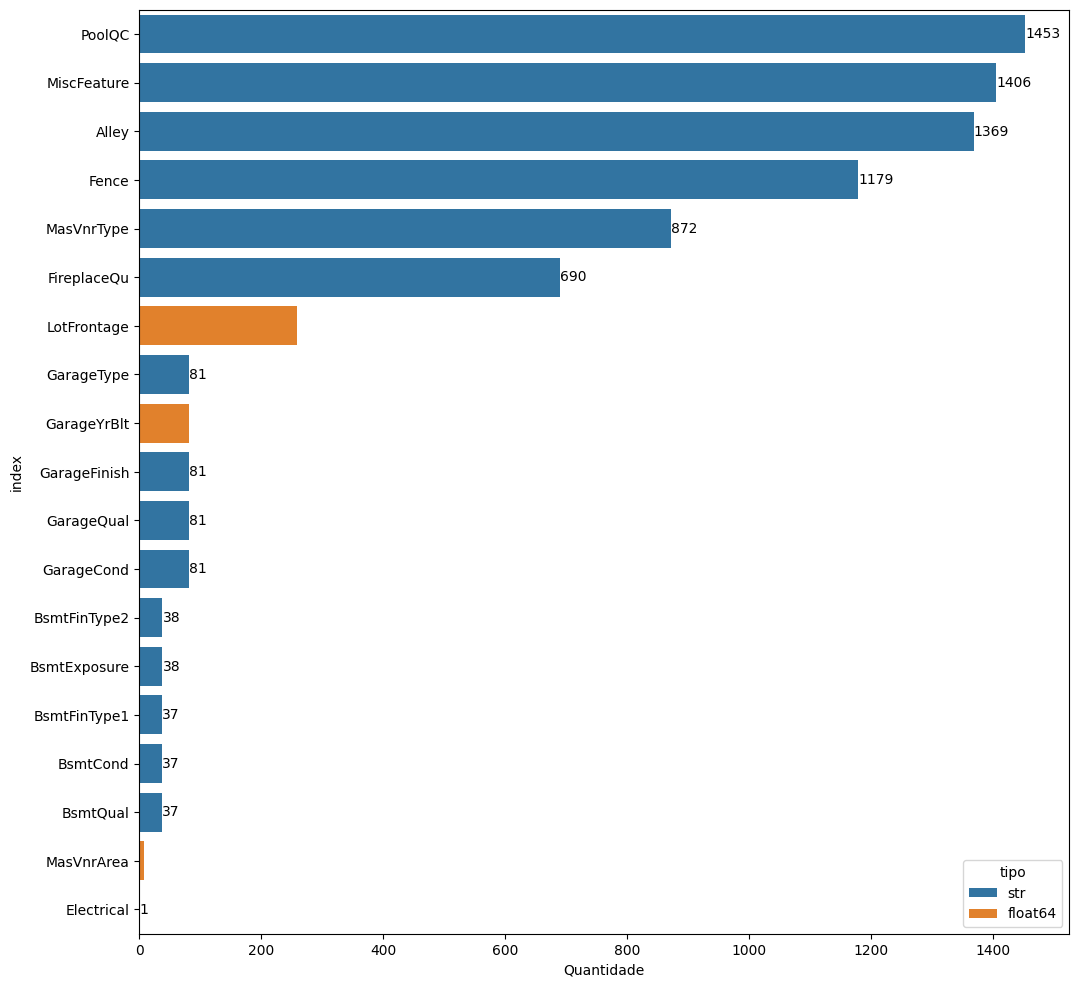

In [6]:
plt.figure(figsize=(12,12))
df_treino_quant_nulos.reset_index()
ax = sns.barplot(
    df_treino_quant_nulos.reset_index(),
    x='Quantidade',
    y='index',
    orient='y',
    hue='tipo'
)
ax.bar_label(ax.containers[0], fontsize=10);


- Se baseando pelo data_description.txt, temos que:
  - NA significa que imovel não possui a característica:
    - PoolQC
    - MiscFeature ( checar se MiscVal = 0 nestes casos)
    - Alley ( 1369 casos; Nem todos os imoveis possuem Alley Access, mas todos possuem Street Access)
    - Fence
    - MasVnrType ( 872 casos; checar se MasVnrArea = 0 nestes casos; Há 8 casos em que MasVnrArea=na)
    - FireplaceQu (provavelmente Fireplaces = 0 nesses casos)
    - Garage features (GarageYrBlt possui a mesma quantidade de na, que essas colunas)
      - GarageType
      - GarageYrBlt
      - GarageFinish
      - GarageQual
      - GarageCond
    - Basement Features 
      - BsmtExposure
      - BsmtFinType2
      - BsmtQual
      - BsmtCond
      - BsmtFinType1
  - Dados faltantes:
    - LotFrontage ( 259 casos; se fosse simplemente o lote nao possuir area conectada a rua, poderia ser LotFrontage=0)
    - GarageYrBlt (81 casos; validar se sao os mesmos casos com os outros garages)
    - MasVnrArea ( 8 casos; checar se MasVnrType = na nesses casos)
    - Electrical ( como só há um caso, talvez possamos apenas dropar este caso)

### Casos em que NA implica que imóvel não possui característica:

- Todos os casos em que MiscFeature = NA implicam que MiscVal = 0

In [7]:
## MiscFeature ( 1406 casos, checar se MiscVal = 0 nestes casos)
df_treino[df_treino['MiscFeature'].isna() & df_treino['MiscVal'] > 0][['MiscFeature','MiscVal']]

,MiscFeature,MiscVal


- Na grande maioria dos casos em que MasVnrType = NA, temos que MasVnrArea = 0 ou tambem é NA
  - Mas em 5 casos, MasVnrArea é diferente; o que indica que nesses casos, MasVnrType está realmente faltando.
  - Talvez vale a pena realizar o drop destes casos, ou preencher estas colunas com o valor mais usado ( que no caso seria o NaN mesmo)
  - Existem 2 casos que possuem MasVnrArea = 1; Seria um dado errado? (outlier?)

In [8]:
## MasVnrType ( 872 casos;checar se MasVnrArea = 0 nestes casos; Há 8 casos em que MasVnrArea=na)
df_treino[df_treino['MasVnrType'].isna() ][['MasVnrType','MasVnrArea']].nunique(dropna=False)

MasVnrType    1
MasVnrArea    6
dtype: int64

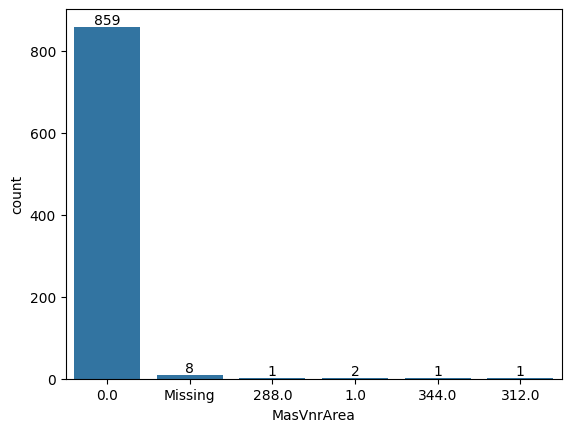

In [9]:
df_treino_masvnrtype_none = df_treino[df_treino['MasVnrType'].isna() ][['MasVnrType','MasVnrArea']]

df_treino_masvnrtype_none['MasVnrArea'] = df_treino_masvnrtype_none['MasVnrArea'].fillna('Missing')

ax = sns.countplot(df_treino_masvnrtype_none,x='MasVnrArea')
ax.bar_label(ax.containers[0], fontsize=10);


- Todos os casos em que FireplaceQu = NA, temos que Fireplaces = 0

In [69]:
## FireplaceQu (690 casos; provavelmente Fireplaces = 0 nesses casos)

df_treino[df_treino['FireplaceQu'].isnull()]['Fireplaces'].value_counts(dropna=False)

Fireplaces
0    690
Name: count, dtype: int64

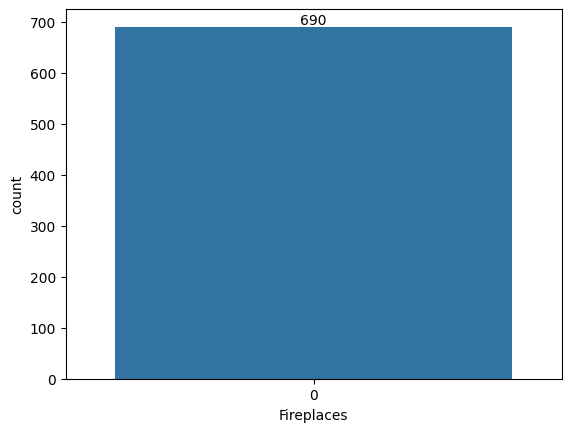

In [70]:


#df_treino[df_treino['FireplaceQu'].isnull()]['Fireplaces'].value_counts()
ax = sns.countplot(df_treino[df_treino['FireplaceQu'].isnull()],x='Fireplaces')
ax.bar_label(ax.containers[0], fontsize=10);

- No caso das variaveis referente a Garage, podemos identificar consistencias entre os valores
- sao 81 casos com valores NA, e nestes casos as variaveis numericas sao iguais a 0

In [105]:
## Garage features (81 casos;GarageYrBlt possui a mesma quantidade de na, que essas colunas)
# GarageType, GarageFinish, GarageQual, GarageCond
# GarageArea, GarageYrBlt

df_treino[df_treino['GarageQual'].isna()][[
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'GarageArea','GarageYrBlt','GarageCars']].value_counts(dropna=False)



GarageType  GarageFinish  GarageQual  GarageCond  GarageArea  GarageYrBlt  GarageCars
NaN         NaN           NaN         NaN         0           NaN          0             81
Name: count, dtype: int64

- Para as variaveis de Basement
- - As que possuem 38 casos
  - - Tem um caso em que BsmtExposure = NA, mas BsmtFinType2 = Unf (unfinished); ou seja uma inconsistencia
    - - Neste caso, provavelmente BsmtExposure deveria ser diferente de NA
      - Temos as outras variaveis numericas com informacao, o que indica que o imovel possui basement
  - - Tem um caso em que BsmtFinType2 = NA, mas BsmtExposure = No (No exposure); ou seja uma inconsistencia
    - - Neste caso, provavelmente o BsmtFinType2 deveria ser diferente de NA
      - Ja que alem do BsmtExposure = No, BsmtFinSF2 > 0
      - Ou seja, ha a presenca do BsmtFinType2, e o imovel possui de fato um basement
- - As que possuem 37 casos
  - - Apresentam conformidade entre si.

In [78]:
## Basement Features 
## Possuem NA:
### 38 casos
# BsmtExposure , BsmtFinType2
### 37 casos
# BsmtQual, BsmtCond, BsmtFinType1
## Todas as features:

#BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1 ,BsmtFinType2, 
# BsmtFinSF1,BsmtFinSF2 ,BsmtUnfSF, TotalBsmtSF, BsmtFullBath, BsmtHalfBath

In [84]:
df_treino[df_treino['BsmtExposure'].isna() | df_treino['BsmtFinType2'].isna()][['BsmtExposure','BsmtFinType2']].value_counts(dropna=False)

BsmtExposure  BsmtFinType2
NaN           NaN             37
No            NaN              1
NaN           Unf              1
Name: count, dtype: int64

In [93]:
df_treino[df_treino['BsmtExposure'].isna() | df_treino['BsmtFinType2'].isna()][
        ['BsmtExposure','BsmtFinType2',
        'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath']
    ].value_counts(dropna=False)

BsmtExposure  BsmtFinType2  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  BsmtFullBath  BsmtHalfBath
NaN           NaN           0           0           0          0            0             0               37
No            NaN           1124        479         1603       3206         1             0                1
NaN           Unf           0           0           936        936          0             0                1
Name: count, dtype: int64

In [83]:
df_treino[df_treino['BsmtQual'].isna()][
    [
        'BsmtExposure','BsmtFinType2',
        'BsmtQual','BsmtCond','BsmtFinType1']
    ].value_counts(dropna=False)

BsmtExposure  BsmtFinType2  BsmtQual  BsmtCond  BsmtFinType1
NaN           NaN           NaN       NaN       NaN             37
Name: count, dtype: int64

In [90]:
df_treino[df_treino['BsmtQual'].isna()][
    [
        'BsmtExposure','BsmtFinType2',
        'BsmtQual','BsmtCond','BsmtFinType1',
        'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath']
    ].value_counts(dropna=False)

BsmtExposure  BsmtFinType2  BsmtQual  BsmtCond  BsmtFinType1  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  BsmtFullBath  BsmtHalfBath
NaN           NaN           NaN       NaN       NaN           0           0           0          0            0             0               37
Name: count, dtype: int64

### Casos em que NA implica Dados faltantes:

In [11]:
## LotFrontage ( 259 casos; validar com street;se fosse simplemente o lote nao possuir area conectada a rua, poderia ser LotFrontage=0)

- Em todos os casos que MasVnrArea = NA, MasVnrType = NA

In [12]:
## MasVnrArea ( 8 casos;  MasVnrType = na nesses casos)
df_treino[df_treino['MasVnrType'].isna() & df_treino['MasVnrArea'].isna()][['MasVnrType','MasVnrArea']]


,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


In [54]:
### 5 casos em que MasVnrArea != 0 com MasVnrType = na
#### 2 destes casos em que MasVnrArea = 1; Outlier?
#df_treino_masvnrtype_none['MasVnrArea'].value_counts()

df_treino[(df_treino['MasVnrArea']<100) & (df_treino['MasVnrArea']>0)]['MasVnrArea'].value_counts()



MasVnrArea
72.0    8
16.0    7
80.0    6
84.0    5
40.0    4
76.0    4
85.0    3
70.0    3
50.0    3
74.0    3
42.0    3
82.0    3
99.0    3
90.0    3
44.0    3
66.0    2
68.0    2
98.0    2
30.0    2
18.0    2
94.0    2
54.0    2
95.0    2
1.0     2
60.0    2
92.0    2
75.0    2
45.0    2
22.0    1
48.0    1
28.0    1
64.0    1
36.0    1
46.0    1
31.0    1
34.0    1
56.0    1
89.0    1
97.0    1
57.0    1
41.0    1
38.0    1
11.0    1
27.0    1
24.0    1
53.0    1
14.0    1
67.0    1
51.0    1
63.0    1
32.0    1
81.0    1
86.0    1
88.0    1
65.0    1
96.0    1
Name: count, dtype: int64

<Axes: xlabel='MasVnrArea', ylabel='Count'>

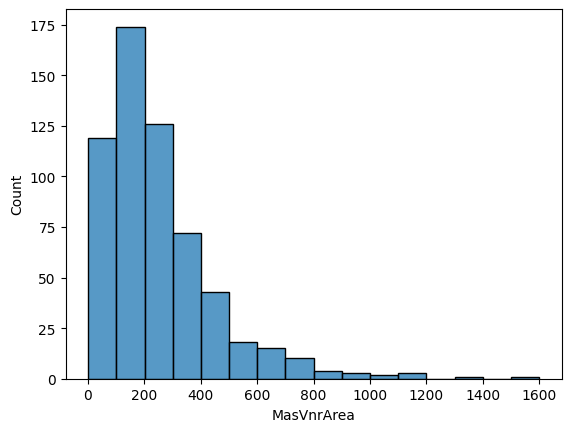

In [47]:
#df_treino['MasVnrArea'].sort_values(ascending=False).value_counts()
sns.histplot(df_treino[df_treino['MasVnrArea']>0], x='MasVnrArea',binwidth=100)

<Axes: xlabel='MasVnrArea', ylabel='Count'>

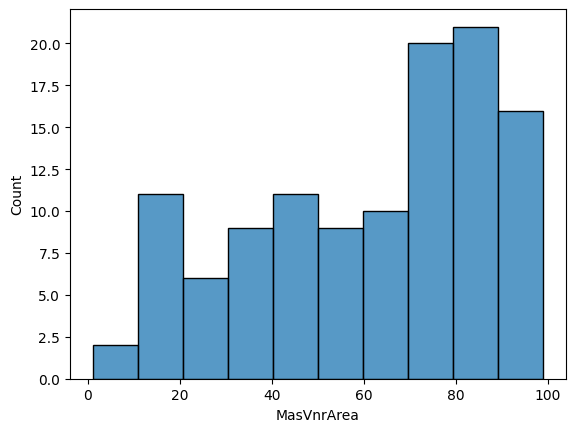

In [46]:
df_treino2 = df_treino[df_treino['MasVnrArea']>0  ]
df_treino2 = df_treino2[ df_treino2['MasVnrArea']<100 ]
#df_treino2
#df_treino[df_treino['MasVnrArea']>0 & df_treino['MasVnrArea']<100 ]
#sns.histplot(df_treino[df_treino['MasVnrArea']>0 & df_treino['MasVnrArea']<100 ], x='MasVnrArea')
sns.histplot(df_treino2 , x='MasVnrArea',binwidth=10)

- O caso em que Electrical eh  nulo aparente ser um caso de dado faltante
- - Uma vez que eh uma residencia MSZoning = RL(Residential Low Density) e Utilities = AllPub (All public Utilities (E,G,W,& S)) 

In [96]:
## Electrical (1 caso, verificar o MSZoning desse caso)
df_treino[df_treino['Electrical'].isna()]


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


## Avaliando correlação entre as variáveis numéricas

- Olhando a correlação entre as variáveis numéricas apenas, podemos ver que em vários casos, há uma alta correlação, o que torna trabalhoso e demorado tratar os dados para usar uma regressão linear multivalorada. 

- Poderíamos inclusive fazer algum agrupamento entre os grandes grupos de variáveis. Por exemplo: há 2 variáveis categóricas que descrevem Roof; há 9 variáveis ( entre numéricas e categóricas) que descrevem Basement; há 7 variáveis (entre numéricas e categóricas) que descrevem Garage; etc

- Vale a pena analisar esses agrupamentos em mais detalhes

<Axes: >

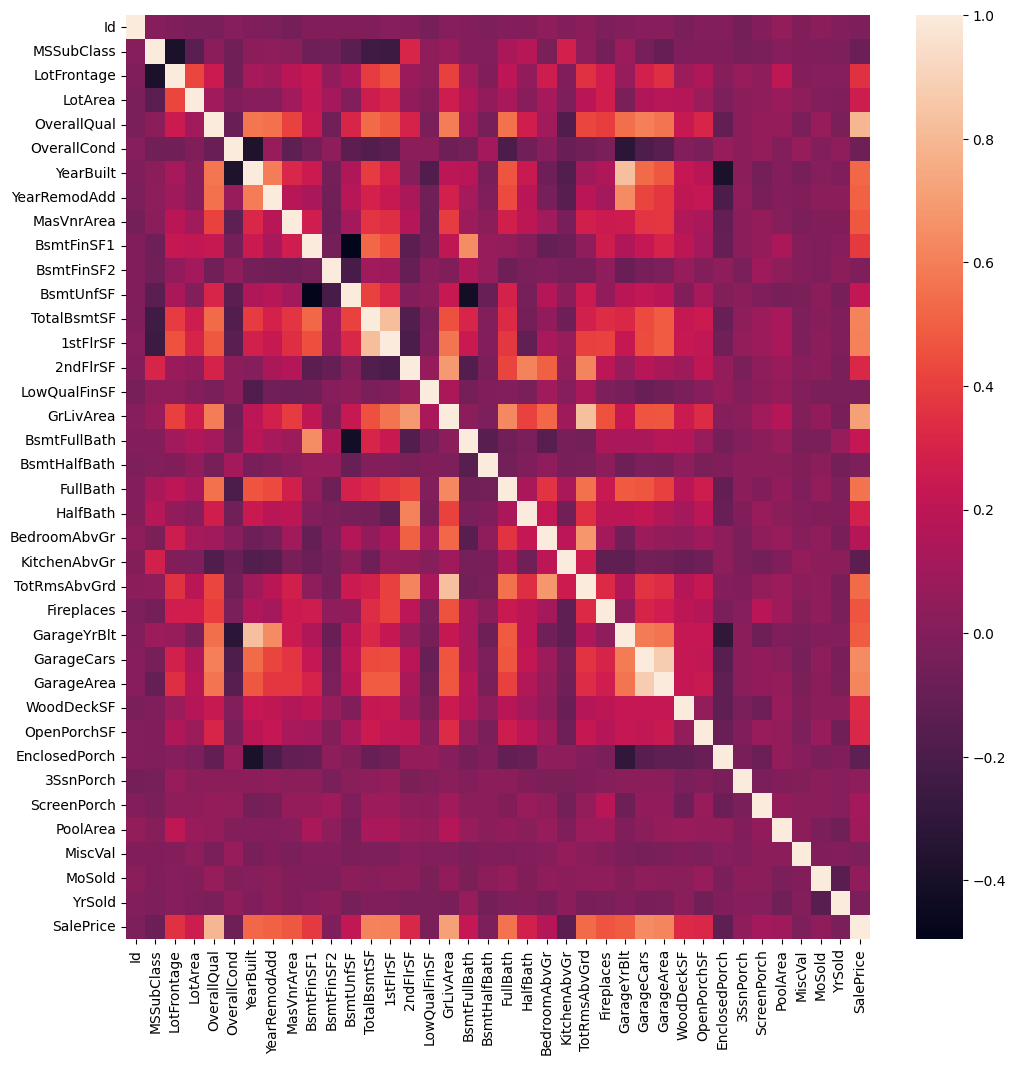

In [15]:
plt.figure(figsize=(12,12))
sns.heatmap(df_treino_numericas.corr())

- Há vários casos com taxa de correlação acima de 50% entre as variáveis numéricas

In [16]:

df_treino_numericas_corr_relevantes = calcular_corr_relevantes(df_treino_numericas)
df_treino_numericas_corr_relevantes

,OverallQual,YearBuilt,YearRemodAdd,BsmtFinSF1,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,GarageYrBlt,GarageCars,GarageArea,SalePrice
OverallQual,NaN,0.572323,0.550684,NaN,0.537808,NaN,NaN,0.593007,NaN,0.550600,NaN,NaN,NaN,0.547766,0.600671,0.562022,0.790982
YearBuilt,0.572323,NaN,0.592855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.825667,0.537850,NaN,0.522897
YearRemodAdd,0.550684,0.592855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.642277,NaN,NaN,0.507101
BsmtFinSF1,NaN,NaN,NaN,NaN,0.522396,NaN,NaN,NaN,0.649212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalBsmtSF,0.537808,NaN,NaN,0.522396,NaN,0.819530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.613581
1stFlrSF,NaN,NaN,NaN,NaN,0.819530,NaN,NaN,0.566024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.605852
2ndFlrSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.687501,NaN,NaN,0.609707,0.502901,0.616423,NaN,NaN,NaN,NaN
GrLivArea,0.593007,NaN,NaN,NaN,NaN,0.566024,0.687501,NaN,NaN,0.630012,NaN,0.521270,0.825489,NaN,NaN,NaN,0.708624
BsmtFullBath,NaN,NaN,NaN,0.649212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FullBath,0.550600,NaN,NaN,NaN,NaN,NaN,NaN,0.630012,NaN,NaN,NaN,NaN,0.554784,NaN,NaN,NaN,0.560664


- A taxa de correlação mais alta de SalePrice está com OverallQual e YearBuilt. Acima de 70%

In [17]:

df_treino_numericas_corr_relevantes['SalePrice'].sort_values(ascending=False).dropna()


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice'>

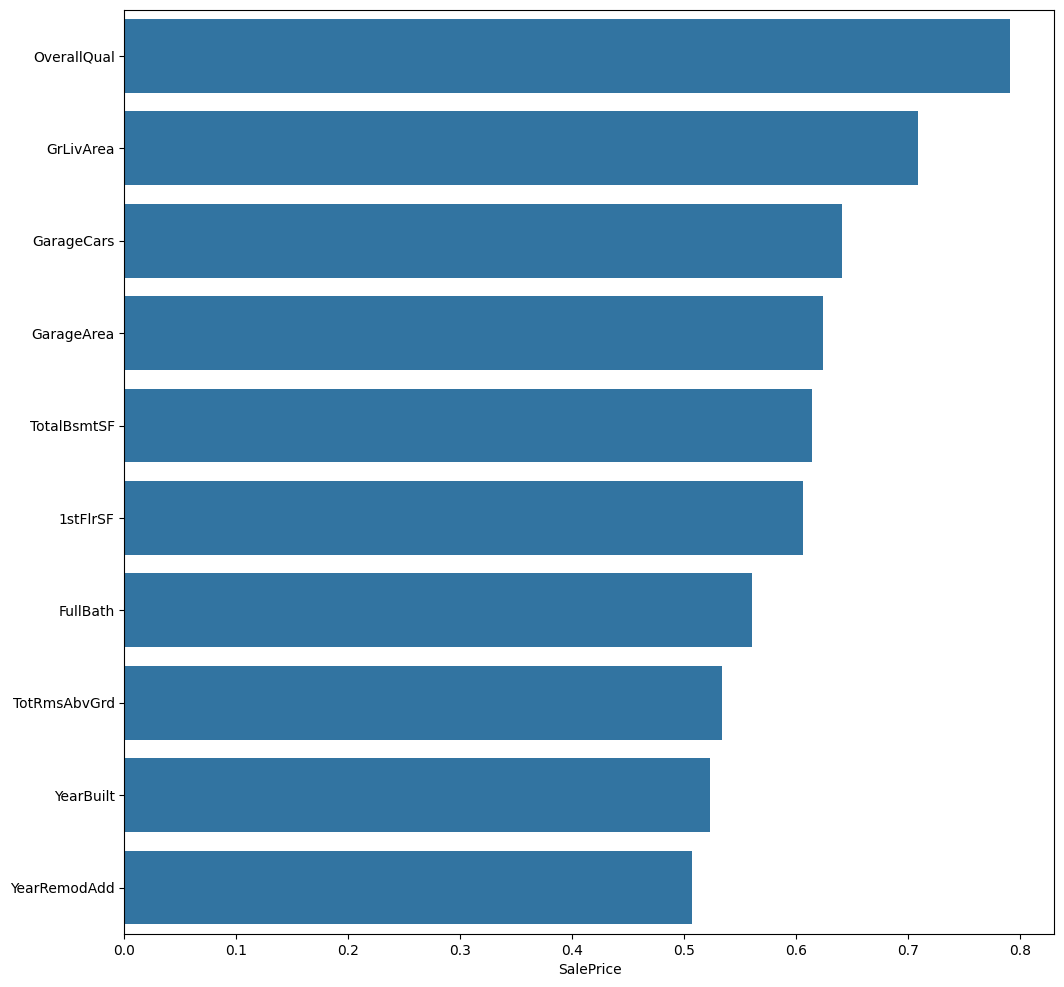

In [18]:
plt.figure(figsize=(12,12))
sns.barplot(
    df_treino_numericas_corr_relevantes['SalePrice'].sort_values(ascending=False).dropna(),
    orient='y'
)

## Avaliando correlação entre as variáveis categóricas

- Importante mapear os casos em que a variável é binária
- - CentralAir

In [19]:
#pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
df_treino_categoricas

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal


## Avaliar os principais agrupamentos observados nas colunas:

- 20 agrupamentos observados

### 1 - dwelling feature analysis

- MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

- MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM	Residential Medium Density

- BldgType: Type of dwelling
		
       1Fam	Single-family Detached	
       2FmCon	Two-family Conversion; originally built as one-family dwelling
       Duplx	Duplex
       TwnhsE	Townhouse End Unit
       TwnhsI	Townhouse Inside Unit
	
- HouseStyle: Style of dwelling
	
       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level

### 2 - Lot feature analysis

- LotFrontage: Linear feet of street connected to property

- LotArea: Lot size in square feet

- Street: Type of road access to property

       Grvl	Gravel	
       Pave	Paved
       	
- Alley: Type of alley access to property

       Grvl	Gravel
       Pave	Paved
       NA 	No alley access

- LotShape: General shape of property

       Reg	Regular	
       IR1	Slightly irregular
       IR2	Moderately Irregular
       IR3	Irregular
       
- LandContour: Flatness of the property

       Lvl	Near Flat/Level	
       Bnk	Banked - Quick and significant rise from street grade to building
       HLS	Hillside - Significant slope from side to side
       Low	Depression

- Utilities: Type of utilities available
		
       AllPub	All public Utilities (E,G,W,& S)	
       NoSewr	Electricity, Gas, and Water (Septic Tank)
       NoSeWa	Electricity and Gas Only
       ELO	Electricity only	

- LotConfig: Lot configuration

       Inside	Inside lot
       Corner	Corner lot
       CulDSac	Cul-de-sac
       FR2	Frontage on 2 sides of property
       FR3	Frontage on 3 sides of property
	
- LandSlope: Slope of property
		
       Gtl	Gentle slope
       Mod	Moderate Slope	
       Sev	Severe Slope

- Neighborhood: Physical locations within Ames city limits

       Blmngtn	Bloomington Heights
       Blueste	Bluestem
       BrDale	Briardale
       BrkSide	Brookside
       ClearCr	Clear Creek
       CollgCr	College Creek
       Crawfor	Crawford
       Edwards	Edwards
       Gilbert	Gilbert
       IDOTRR	Iowa DOT and Rail Road
       MeadowV	Meadow Village
       Mitchel	Mitchell
       Names	North Ames
       NoRidge	Northridge
       NPkVill	Northpark Villa
       NridgHt	Northridge Heights
       NWAmes	Northwest Ames
       OldTown	Old Town
       SWISU	South & West of Iowa State University
       Sawyer	Sawyer
       SawyerW	Sawyer West
       Somerst	Somerset
       StoneBr	Stone Brook
       Timber	Timberland
       Veenker	Veenker
			
- Condition1: Proximity to various conditions
	
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad
	
- Condition2: Proximity to various conditions (if more than one is present)
		
       Artery	Adjacent to arterial street
       Feedr	Adjacent to feeder street	
       Norm	Normal	
       RRNn	Within 200' of North-South Railroad
       RRAn	Adjacent to North-South Railroad
       PosN	Near positive off-site feature--park, greenbelt, etc.
       PosA	Adjacent to postive off-site feature
       RRNe	Within 200' of East-West Railroad
       RRAe	Adjacent to East-West Railroad

### 3 - overall quality feature analysis

- OverallQual: Rates the overall material and finish of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor
	
- OverallCond: Rates the overall condition of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average	
       5	Average
       4	Below Average	
       3	Fair
       2	Poor
       1	Very Poor
		

###  4 - year feature analysis

- YearBuilt: Original construction date

- YearRemodAdd: Remodel date (same as construction date if no remodeling or additions)

- GarageYrBlt: Year garage was built

###  5 - roof feature analysis

- RoofStyle: Type of roof

       Flat	Flat
       Gable	Gable
       Gambrel	Gabrel (Barn)
       Hip	Hip
       Mansard	Mansard
       Shed	Shed
		
- RoofMatl: Roof material

       ClyTile	Clay or Tile
       CompShg	Standard (Composite) Shingle
       Membran	Membrane
       Metal	Metal
       Roll	Roll
       Tar&Grv	Gravel & Tar
       WdShake	Wood Shakes
       WdShngl	Wood Shingles

###  6 - exterior feature analysis

- Exterior1st: Exterior covering on house

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast	
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
- Exterior2nd: Exterior covering on house (if more than one material)

       AsbShng	Asbestos Shingles
       AsphShn	Asphalt Shingles
       BrkComm	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       CemntBd	Cement Board
       HdBoard	Hard Board
       ImStucc	Imitation Stucco
       MetalSd	Metal Siding
       Other	Other
       Plywood	Plywood
       PreCast	PreCast
       Stone	Stone
       Stucco	Stucco
       VinylSd	Vinyl Siding
       Wd Sdng	Wood Siding
       WdShing	Wood Shingles
	
- MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	None
       Stone	Stone
	
- MasVnrArea: Masonry veneer area in square feet

- ExterQual: Evaluates the quality of the material on the exterior 
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
- ExterCond: Evaluates the present condition of the material on the exterior
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor

- Fence: Fence quality
		
       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence

###  7 - basement feature analysis

- Foundation: Type of foundation
		
       BrkTil	Brick & Tile
       CBlock	Cinder Block
       PConc	Poured Contrete	
       Slab	Slab
       Stone	Stone
       Wood	Wood
		
- BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
- BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
	
- BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement
	
- BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
		
- BsmtFinSF1: Type 1 finished square feet

- BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

- BsmtFinSF2: Type 2 finished square feet

- BsmtUnfSF: Unfinished square feet of basement area

- TotalBsmtSF: Total square feet of basement area

- BsmtFullBath: Basement full bathrooms

- BsmtHalfBath: Basement half bathrooms


- Provavelmente há alta correlação entre:
- - BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF

###  8 - heating;air;eletrical;functional feature analysis

- Heating: Type of heating
		
       Floor	Floor Furnace
       GasA	Gas forced warm air furnace
       GasW	Gas hot water or steam heat
       Grav	Gravity furnace	
       OthW	Hot water or steam heat other than gas
       Wall	Wall furnace
		
- HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor
		
- CentralAir: Central air conditioning

       N	No
       Y	Yes
		
- Electrical: Electrical system

       SBrkr	Standard Circuit Breakers & Romex
       FuseA	Fuse Box over 60 AMP and all Romex wiring (Average)	
       FuseF	60 AMP Fuse Box and mostly Romex wiring (Fair)
       FuseP	60 AMP Fuse Box and mostly knob & tube wiring (poor)
       Mix	Mixed

- Functional: Home functionality (Assume typical unless deductions are warranted)

       Typ	Typical Functionality
       Min1	Minor Deductions 1
       Min2	Minor Deductions 2
       Mod	Moderate Deductions
       Maj1	Major Deductions 1
       Maj2	Major Deductions 2
       Sev	Severely Damaged
       Sal	Salvage only


CentralAir é uma variável binária, logo podemos fatorizar ela.

###  9 - Area above grade feature analysis

- 1stFlrSF: First Floor square feet
 
- 2ndFlrSF: Second floor square feet

- LowQualFinSF: Low quality finished square feet (all floors)

- GrLivArea: Above grade (ground) living area square feet

- FullBath: Full bathrooms above grade

- HalfBath: Half baths above grade

- Bedroom: Bedrooms above grade (does NOT include basement bedrooms)

- Kitchen: Kitchens above grade

- KitchenQual: Kitchen quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       	
- TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)



###  10 - Fireplaces feature analysis

- Fireplaces: Number of fireplaces

- FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace

Talvez exista relação entre essa variavel com

- LotFrontage
- Street
- Alley

###  11 - Garage feature analysis

- GarageType: Garage location
		
       2Types	More than one type of garage
       Attchd	Attached to home
       Basment	Basement Garage
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       CarPort	Car Port
       Detchd	Detached from home
       NA	No Garage
		
- GarageYrBlt: Year garage was built
		
- GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage
		
- GarageCars: Size of garage in car capacity

- GarageArea: Size of garage in square feet

- GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
- GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
- PavedDrive: Paved driveway

       Y	Paved 
       P	Partial Pavement
       N	Dirt/Gravel


Talvez exista relação entre 
- Paved driveway,Street,alley
- GarageYrBlt ,YearBuilt

###  12 - Porch feature analysis

- WoodDeckSF: Wood deck area in square feet

- OpenPorchSF: Open porch area in square feet

- EnclosedPorch: Enclosed porch area in square feet

- 3SsnPorch: Three season porch area in square feet

- ScreenPorch: Screen porch area in square feet

###  13 - Pool feature analysis

- PoolArea: Pool area in square feet

- PoolQC: Pool quality
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       NA	No Pool

###  14 - Misc feature analysis

- MiscFeature: Miscellaneous feature not covered in other categories
		
       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None
		
- MiscVal: $Value of miscellaneous feature

###  15 - Sale feature analysis

- MoSold: Month Sold (MM)

- YrSold: Year Sold (YYYY)

- SaleType: Type of sale
		
       WD 	Warranty Deed - Conventional
       CWD	Warranty Deed - Cash
       VWD	Warranty Deed - VA Loan
       New	Home just constructed and sold
       COD	Court Officer Deed/Estate
       Con	Contract 15% Down payment regular terms
       ConLw	Contract Low Down payment and low interest
       ConLI	Contract Low Interest
       ConLD	Contract Low Down
       Oth	Other
		
- SaleCondition: Condition of sale

       Normal	Normal Sale
       Abnorml	Abnormal Sale -  trade, foreclosure, short sale
       AdjLand	Adjoining Land Purchase
       Alloca	Allocation - two linked properties with separate deeds, typically condo with a garage unit	
       Family	Sale between family members
       Partial	Home was not completed when last assessed (associated with New Homes)


Talvez exista relação entre:
- YrSold, YearBuilt, YearRemodAdd

###  16 - Bathroom feature analysis

Uma interseção entre variáveis de banheiro nas areas de basement e above grade


- BsmtFullBath: Basement full bathrooms

- BsmtHalfBath: Basement half bathrooms

- FullBath: Full bathrooms above grade

- HalfBath: Half baths above grade

###  17 Condition feature analysis

Intersecao entre as diferentes variaveis de condition

- OverallCond: Rates the overall condition of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average	
       5	Average
       4	Below Average	
       3	Fair
       2	Poor
       1	Very Poor

- ExterCond: Evaluates the present condition of the material on the exterior
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	

- BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement

- HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor

- GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage

Interessante observar que para o Heating, foi criado uma única variável agregando condition e quality, diferente dos outros casos

###  18 - Quality feature analysis

Intersecao entre as diferentes variaveis de quality

- OverallQual: Rates the overall material and finish of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor

- ExterQual: Evaluates the quality of the material on the exterior 
		
       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor

- BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No 

- HeatingQC: Heating quality and condition

       Ex	Excellent
       Gd	Good
       TA	Average/Typical
       Fa	Fair
       Po	Poor

- GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage



###  19 - Finish feature analysis

- Intersecao entre as diferentes variaveis de finish;
- Há uma certa interseção com as variáveis de quality

- HouseStyle: Style of dwelling
	
       1Story	One story
       1.5Fin	One and one-half story: 2nd level finished
       1.5Unf	One and one-half story: 2nd level unfinished
       2Story	Two story
       2.5Fin	Two and one-half story: 2nd level finished
       2.5Unf	Two and one-half story: 2nd level unfinished
       SFoyer	Split Foyer
       SLvl	Split Level

- OverallQual: Rates the overall material and finish of the house

       10	Very Excellent
       9	Excellent
       8	Very Good
       7	Good
       6	Above Average
       5	Average
       4	Below Average
       3	Fair
       2	Poor
       1	Very Poor

- BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

- BsmtFinSF1: Type 1 finished square feet

- BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

- BsmtFinSF2: Type 2 finished square feet

- BsmtUnfSF: Unfinished square feet of basement area

- LowQualFinSF: Low quality finished square feet (all floors)

- GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage

- Provavelmente há alta correlação entre:
- - BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF

###  20 - Area feature analysis

Intersecao entre as diferentes variaveis de area (square feet)

- LotArea: Lot size in square feet
  
- MasVnrArea: Masonry veneer area in square feet
  
- BsmtFinSF1: Type 1 finished square feet
  
- BsmtFinSF2: Type 2 finished square feet

- BsmtUnfSF: Unfinished square feet of basement area

- TotalBsmtSF: Total square feet of basement area

- 1stFlrSF: First Floor square feet
 
- 2ndFlrSF: Second floor square feet

- LowQualFinSF: Low quality finished square feet (all floors)

- GrLivArea: Above grade (ground) living area square feet

- GarageArea: Size of garage in square feet

- WoodDeckSF: Wood deck area in square feet

- OpenPorchSF: Open porch area in square feet

- EnclosedPorch: Enclosed porch area in square feet

- 3SsnPorch: Three season porch area in square feet

- ScreenPorch: Screen porch area in square feet

- PoolArea: Pool area in square feet

# Data Pre Processing

## Numerical Data

In [20]:
# Remover ID
df_treino = df_treino.drop(['Id'],axis=1)
# Tratar casos nulos
## Dados faltante:
### Eletrical (1 caso)
### LotFrontage (259 casos)
### MasVnrArea ( 8 casos)

## Categorical Data

In [21]:
# Tratar casos em que a variável é binária
## CentralAir
## Street

# Tratar casos nulos
## casos em que o valor é nulo pq o imóvei não possui aquela característica; portanto deve ter uma dummy correspondente
### pollQc
### MasVnrType

# Criar variáveis dummys
## casos com dummy_na:
### pollQc

# Training Model

In [22]:
# RandomForestRegressor

# Evaluating